
# CIA4 — End-to-End NLP Project Notebook  
## AI-Driven Text Analysis of Customer Subscription Cancellation Feedback to Understand Churn Drivers and Retention Opportunities

This notebook is designed for your **CIA4 Departmental Project on Text Analytics and AI**.

It covers:
- data loading and audit
- text preprocessing
- exploratory analysis
- word cloud and n-gram analysis
- sentiment analysis
- topic modeling (LDA)
- word co-occurrence network
- clustering (K-Means)
- weakly supervised classification for **return intent / retention opportunity**
- export of key outputs

> Update the markdown interpretations and prompt log cells after running the notebook with your final observations.



## 1. Prompt Log for GenAI Usage

Since your faculty asked you to **furnish all prompts used for coding**, keep your prompts here.

**Example prompts**
1. *Generate Python code to clean and preprocess open-ended survey text for NLP analysis.*
2. *Write Python code to create a word cloud and top bigram chart from customer feedback.*
3. *Help me build an LDA topic model to identify churn drivers from subscription cancellation responses.*
4. *Write Python code to predict return intent from customer cancellation feedback using TF-IDF and classification models.*
5. *Help me interpret topic modeling, sentiment, clustering, and business implications for a subscription churn dataset.*

Add your exact prompts below before submission.


In [3]:

# Core imports
import os
import re
import math
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from textblob import TextBlob
from wordcloud import WordCloud
import networkx as nx

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = "subscription_churn_responses_form_format.xlsx"
OUTPUT_DIR = "cia4_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Working directory:", os.getcwd())
print("Data path exists:", os.path.exists(DATA_PATH))
print("Output folder:", OUTPUT_DIR)


Working directory: c:\Text_Analytics\CIA3\main
Data path exists: True
Output folder: cia4_outputs


In [4]:

# 2. Load the dataset

df = pd.read_excel(DATA_PATH)
print("Original shape:", df.shape)
df.head(3)


Original shape: (127, 9)


,Timestamp,Please enter your gender,Please enter your age,Please enter your monthly income range,"“Please share your detailed opinions about the following aspects of the subscription service. For each attribute, describe your experience and perception:”\nContent or Service Quality:\nHow satisfied were you with the quality, usefulness, or relevance of the service provided?\nPricing & Value for Money:\nDid you feel the subscription price matched the value you received?\nUser Experience & Convenience:\nHow easy was it to use the platform or access the service?\nCustomer Support:\nWhat was your experience with customer service or issue resolution?\nFeatures & Innovation:\nDid the service offer enough features or improvements to keep you engaged?","“Please share your detailed opinions about the following aspects of the subscription service. For each attribute, describe your experience and perception:”\nContent or Service Quality:\nHow satisfied were you with the quality, usefulness, or relevance of the service provided?\nPricing & Value for Money:\nDid you feel the subscription price matched the value you received?\nUser Experience & Convenience:\nHow easy was it to use the platform or access the service?\nCustomer Support:\nWhat was your experience with customer service or issue resolution?\nFeatures & Innovation:\nDid the service offer enough features or improvements to keep you engaged?.1","“Please describe how you used the subscription service during the time you were subscribed.\nFor example:\nHow frequently did you use the service?\nIn what situations or contexts did you find it most useful?\nDid your usage change over time? If so, explain why.\nIf your usage declined before cancellation, please describe what caused this change.”","“Before cancelling the subscription, were there any warning signs or frustrations that made you feel dissatisfied with the service?\nPlease describe any specific pain points you experienced, such as:\nPoor service quality\nTechnical issues or usability problems\nHigh pricing\nLack of relevant content or features\nBetter alternatives available\nReduced personal need for the service\nExplain how these issues influenced your decision to cancel.”","“Subscriptions often create emotional or functional connections with users.\nPlease describe how you felt about the service before cancelling it. For example, did you feel satisfied, indifferent, frustrated, disappointed, or something else?\nAdditionally:\nWould you consider returning to this subscription in the future? Why or why not?\nWhat changes or improvements would make you reconsider using the service again?\nIf possible, describe your experience as a short story of your journey with the service — from when you first subscribed to the moment you decided to cancel.”"
0,2026-05-03 08:14:22,Male,39,"₹80,000–₹1,20,000",I remember subscribing to Coursera since many of my friends recommended it. Eventually I decided the cost was not worth the value I was getting.,"If I break it down: the service quality was okay overall. Pricing was the main concern for me. The app design was simple enough to use daily. I didn't interact much with support, but innovation on...",At first it became part of my daily routine. Later my usage dropped because work became busy.,The turning point came after noticing some consistent problems. The platform sometimes felt repetitive and predictable. That gradually influenced my decision to cancel the subscription.,"From an emotional perspective, initially I was quite satisfied. A better value plan could definitely bring me back."
1,2026-05-03 08:57:31,Male,34,"₹80,000–₹1,20,000",At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it.,"Regarding quality, it was decent but not outstanding. Pricing felt slightly high from an Indian perspective. The interface itself was fairly easy to navigate, although I noticed occasional lag. Cu...",In the beginning I used it quite fre

In [5]:

# 3. Rename columns for convenience

expected_cols = [
    "timestamp",
    "gender",
    "age",
    "income",
    "overall_experience",
    "service_attribute_evaluation",
    "usage_context",
    "pain_points",
    "emotional_loyalty_future"
]

if len(df.columns) == len(expected_cols):
    df.columns = expected_cols
else:
    print("Column count changed. Review the raw columns manually.")
    print(df.columns.tolist())

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   timestamp                     127 non-null    datetime64[us]
 1   gender                        127 non-null    str           
 2   age                           127 non-null    int64         
 3   income                        127 non-null    str           
 4   overall_experience            127 non-null    str           
 5   service_attribute_evaluation  127 non-null    str           
 6   usage_context                 127 non-null    str           
 7   pain_points                   127 non-null    str           
 8   emotional_loyalty_future      127 non-null    str           
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 9.1 KB


In [6]:

# 4. Basic data audit

audit = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_values": [df[c].isna().sum() for c in df.columns],
    "non_null_values": [df[c].notna().sum() for c in df.columns],
    "unique_values": [df[c].nunique(dropna=True) for c in df.columns]
})

audit


,column,dtype,missing_values,non_null_values,unique_values
0,timestamp,datetime64[us],0,127,127
1,gender,str,0,127,4
2,age,int64,0,127,42
3,income,str,0,127,5
4,overall_experience,str,0,127,123
5,service_attribute_evaluation,str,0,127,4
6,usage_context,str,0,127,25
7,pain_points,str,0,127,25
8,emotional_loyalty_future,str,0,127,65


In [7]:

# 5. Clean basic fields

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["age"] = pd.to_numeric(df["age"], errors="coerce")

text_cols = [
    "overall_experience",
    "service_attribute_evaluation",
    "usage_context",
    "pain_points",
    "emotional_loyalty_future"
]

for col in text_cols:
    df[col] = df[col].fillna("").astype(str).str.strip()

df["combined_text"] = df[text_cols].agg(" ".join, axis=1).str.replace(r"\s+", " ", regex=True).str.strip()

print("Final shape:", df.shape)
print("Exact duplicate combined responses:", df["combined_text"].duplicated().sum())
df[["gender", "age", "income", "combined_text"]].head(2)


Final shape: (127, 10)
Exact duplicate combined responses: 0


,gender,age,income,combined_text
0,Male,39,"₹80,000–₹1,20,000",I remember subscribing to Coursera since many of my friends recommended it. Eventually I decided the cost was not worth the value I was getting. If I break it down: the service quality was okay ov...
1,Male,34,"₹80,000–₹1,20,000","At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it. Regarding quality, it was decent but not outstanding. Pricing felt slig..."


## 2. Demographic Overview

,count
gender,
Male,35
Female,34
Non-binary,33
Prefer not to say,25


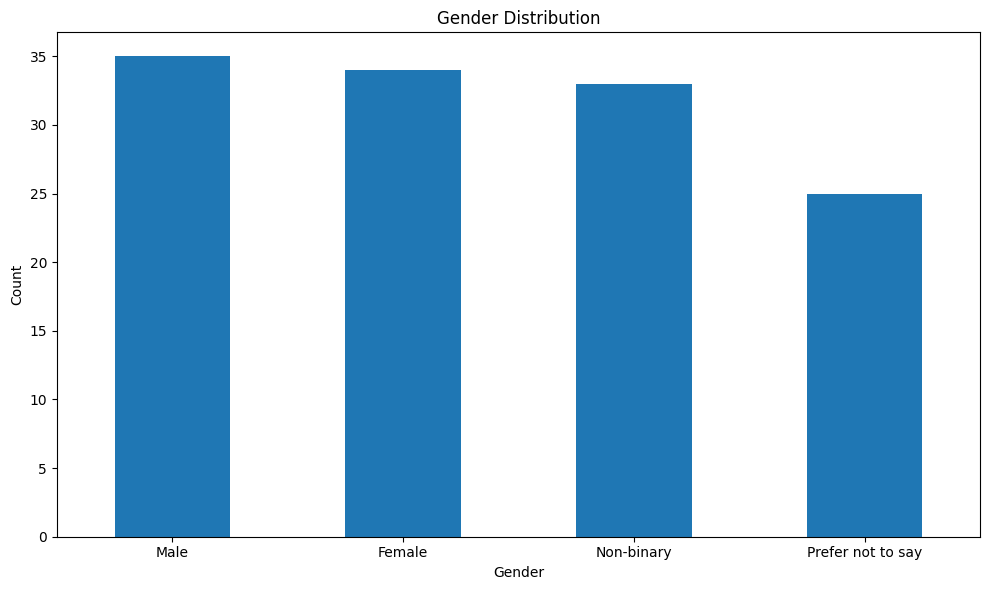

In [8]:

# 6. Gender distribution

gender_counts = df["gender"].fillna("Missing").value_counts()
display(gender_counts.to_frame("count"))

plt.figure()
gender_counts.plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


count    127.000000
mean      38.771654
std       14.724016
min       18.000000
25%       25.500000
50%       37.000000
75%       52.500000
max       65.000000
Name: age, dtype: float64


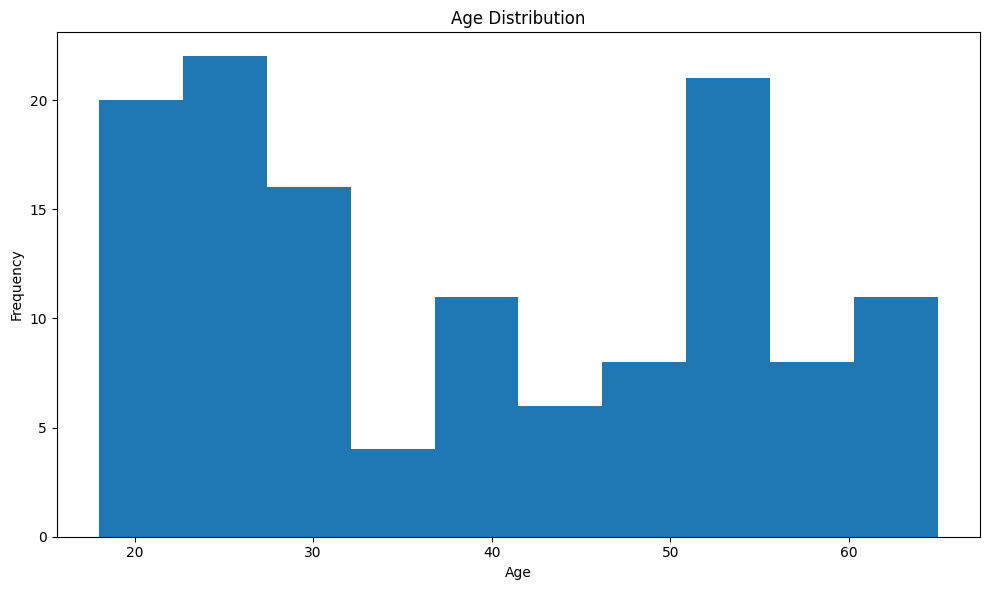

In [9]:

# 7. Age distribution

print(df["age"].describe())

plt.figure()
df["age"].dropna().plot(kind="hist", bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


,count
income,
"₹80,000–₹1,20,000",38
"₹25,000–₹50,000",28
"Above ₹1,20,000",26
"₹50,000–₹80,000",19
"Below ₹25,000",16


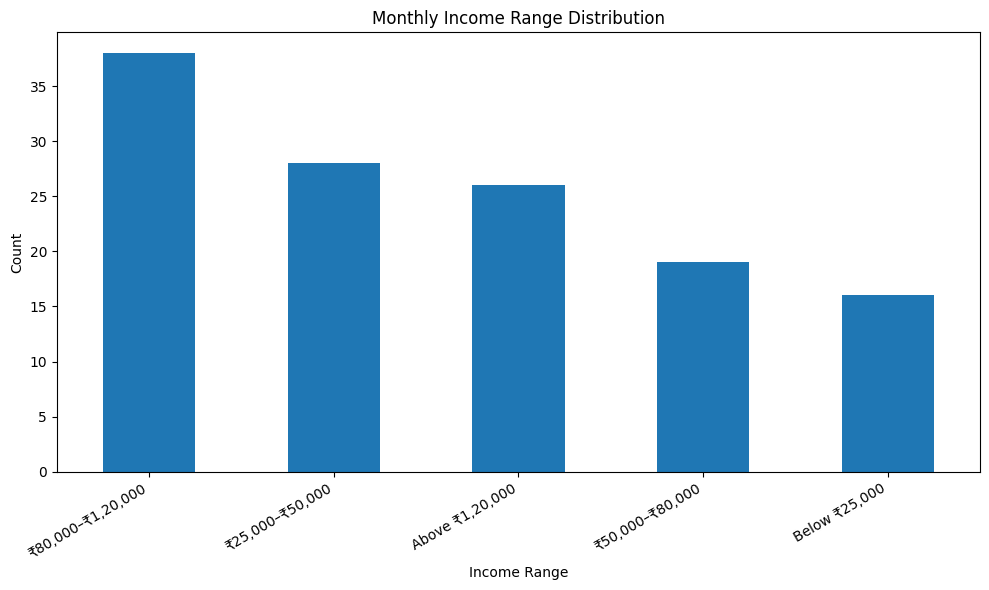

In [10]:

# 8. Monthly income distribution

income_counts = df["income"].fillna("Missing").value_counts()
display(income_counts.to_frame("count"))

plt.figure()
income_counts.plot(kind="bar")
plt.title("Monthly Income Range Distribution")
plt.xlabel("Income Range")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 3. Text Preprocessing

In [11]:

# 9. Preprocess the combined text

base_stopwords = set(ENGLISH_STOP_WORDS)

# Domain-specific filler terms that otherwise dominate results
domain_stopwords = {
    "subscription", "service", "cancel", "cancelled", "cancelling", "overall",
    "experience", "please", "describe", "aspect", "aspects", "customer", "customers",
    "platform", "company", "quality", "content", "pricing", "value", "money",
    "features", "feature", "support", "user", "users", "using", "used", "use",
    "feel", "felt", "would", "could", "also", "really", "quite", "still", "one",
    "get", "got", "make", "made", "thing", "things"
}
STOPWORDS = base_stopwords.union(domain_stopwords)

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)

df["clean_text"] = df["combined_text"].apply(clean_text)
df["word_count"] = df["clean_text"].str.split().str.len()

print(df["word_count"].describe())
df[["combined_text", "clean_text"]].head(2)


count    127.000000
mean      48.488189
std        4.054913
min       38.000000
25%       46.000000
50%       48.000000
75%       51.000000
max       57.000000
Name: word_count, dtype: float64


,combined_text,clean_text
0,I remember subscribing to Coursera since many of my friends recommended it. Eventually I decided the cost was not worth the value I was getting. If I break it down: the service quality was okay ov...,remember subscribing coursera friends recommended eventually decided cost worth getting break okay main concern app design simple daily didn interact innovation limited daily routine later usage d...
1,"At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it. Regarding quality, it was decent but not outstanding. Pricing felt slig...",point actively cloud storage plan trial offer gradually lost regarding decent outstanding slightly high indian perspective interface fairly easy navigate noticed occasional lag polite slow expecte...


In [12]:

# 10. Remove empty rows after cleaning (if any)

analysis_df = df[df["clean_text"].str.len() > 0].copy()
print("Rows available for analysis:", len(analysis_df))
analysis_df[["clean_text", "word_count"]].head(2)


Rows available for analysis: 127


,clean_text,word_count
0,remember subscribing coursera friends recommended eventually decided cost worth getting break okay main concern app design simple daily didn interact innovation limited daily routine later usage d...,48
1,point actively cloud storage plan trial offer gradually lost regarding decent outstanding slightly high indian perspective interface fairly easy navigate noticed occasional lag polite slow expecte...,52


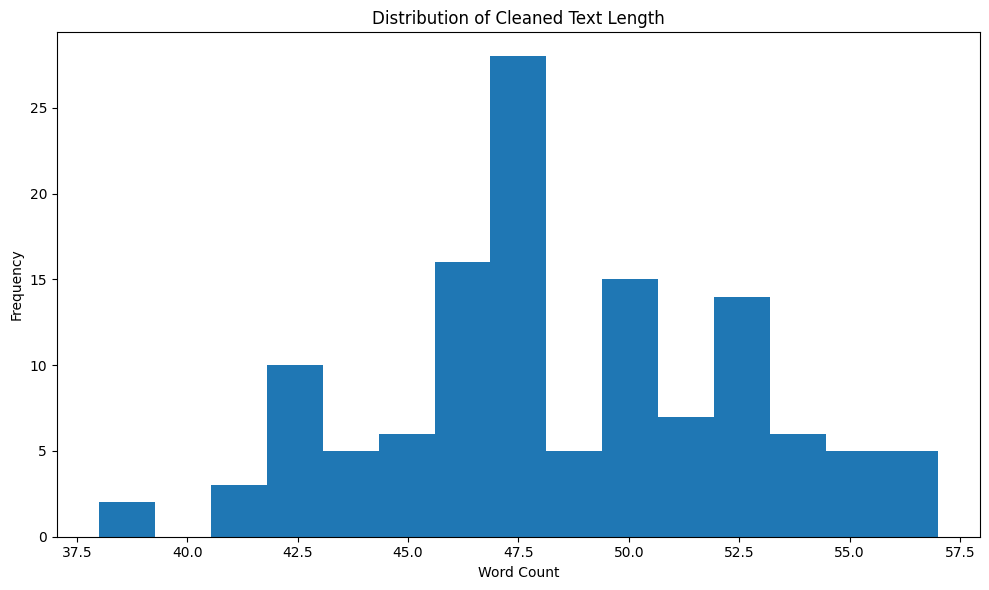

In [13]:

# 11. Text length distribution

plt.figure()
analysis_df["word_count"].plot(kind="hist", bins=15)
plt.title("Distribution of Cleaned Text Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 4. Word Cloud, Unigrams, Bigrams, and Trigrams

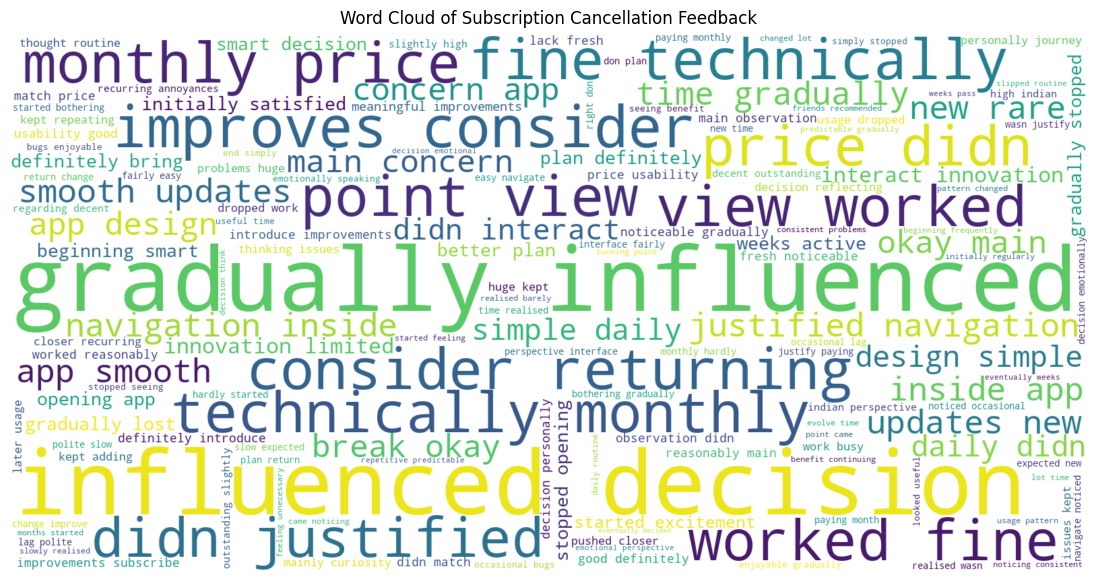

In [14]:

# 12. Word cloud

all_text = " ".join(analysis_df["clean_text"].tolist())

wc = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=150
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Subscription Cancellation Feedback")
plt.show()


In [15]:

# 13. Helper function for top n-grams

def top_ngrams(text_series, ngram_range=(1, 1), top_n=20, min_df=2):
    vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vectorizer.fit_transform(text_series)
    frequencies = np.asarray(X.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    out = pd.DataFrame({"term": terms, "frequency": frequencies})
    out = out.sort_values("frequency", ascending=False).head(top_n).reset_index(drop=True)
    return out

top_unigrams = top_ngrams(analysis_df["clean_text"], (1, 1), top_n=20, min_df=2)
top_bigrams = top_ngrams(analysis_df["clean_text"], (2, 2), top_n=20, min_df=2)
top_trigrams = top_ngrams(analysis_df["clean_text"], (3, 3), top_n=20, min_df=2)

display(top_unigrams)
display(top_bigrams.head(10))
display(top_trigrams.head(10))


,term,frequency
0,gradually,194
1,decision,160
2,time,146
3,app,131
4,influenced,127
5,didn,101
6,started,95
7,point,76
8,routine,75
9,plan,68


,term,frequency
0,gradually influenced,127
1,influenced decision,127
2,improves consider,37
3,consider returning,37
4,technically monthly,36
5,price didn,36
6,point view,36
7,new rare,36
8,fine technically,36
9,view worked,36


,term,frequency
0,gradually influenced decision,127
1,improves consider returning,37
2,updates new rare,36
3,app smooth updates,36
4,didn justified navigation,36
5,smooth updates new,36
6,fine technically monthly,36
7,technically monthly price,36
8,view worked fine,36
9,justified navigation inside,36


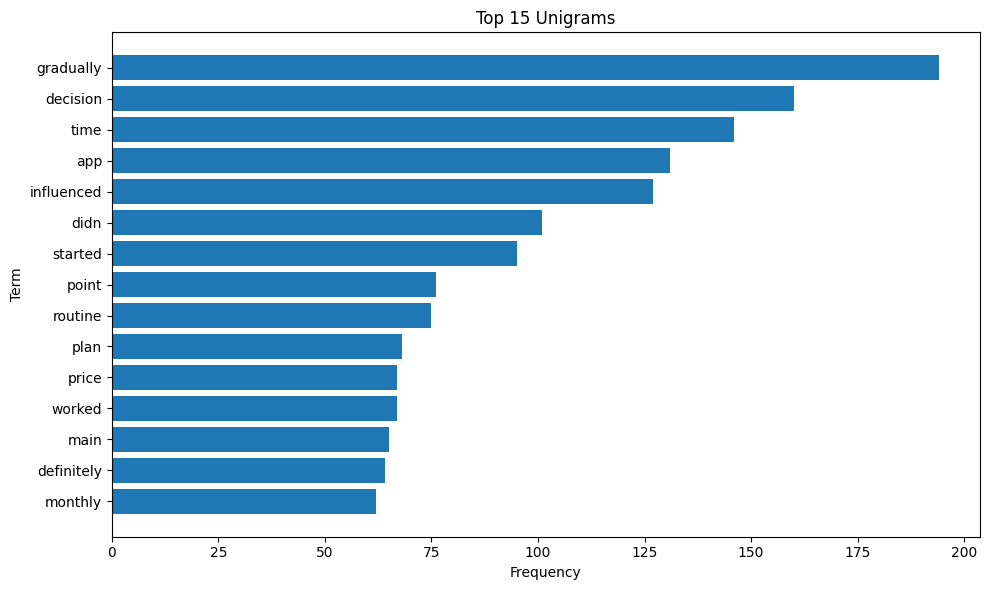

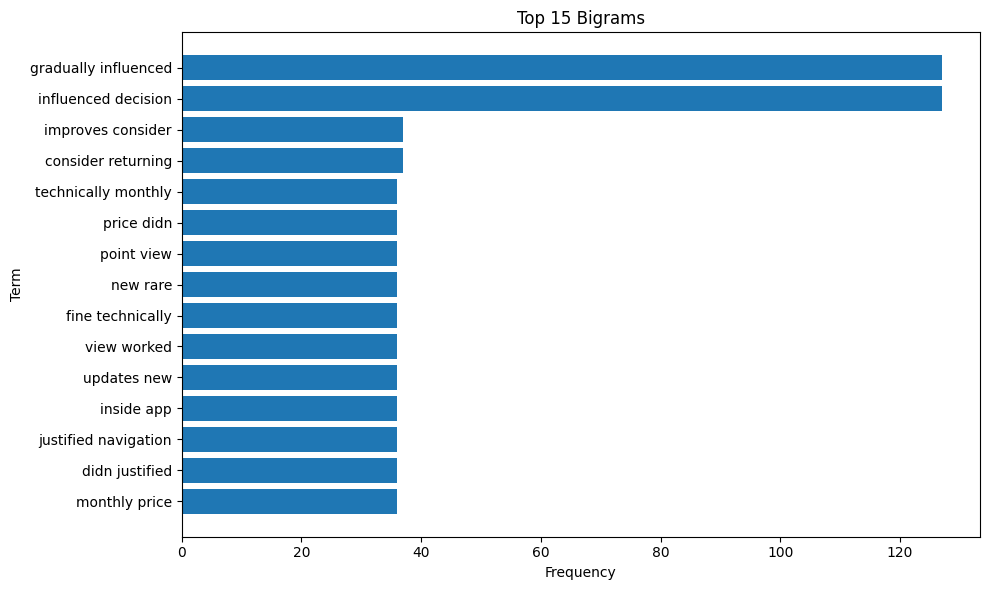

In [16]:

# 14. Plot top unigrams and bigrams

def plot_top_terms(df_terms, title):
    plt.figure(figsize=(10, 6))
    plt.barh(df_terms["term"][::-1], df_terms["frequency"][::-1])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Term")
    plt.tight_layout()
    plt.show()

plot_top_terms(top_unigrams.head(15), "Top 15 Unigrams")
plot_top_terms(top_bigrams.head(15), "Top 15 Bigrams")


## 5. Sentiment Analysis

,count
sentiment_label,
Neutral/Mixed,62
Positive,55
Negative/Concern,10


,polarity,subjectivity,sentiment_label
count,127.000000,127.000000,127
unique,NaN,NaN,3
top,NaN,NaN,Neutral/Mixed
freq,NaN,NaN,62
mean,0.106294,0.390182,NaN
std,0.053666,0.072028,NaN
min,-0.012396,0.203193,NaN
25%,0.065491,0.325568,NaN
50%,0.102666,0.410808,NaN
75%,0.148246,0.443734,NaN


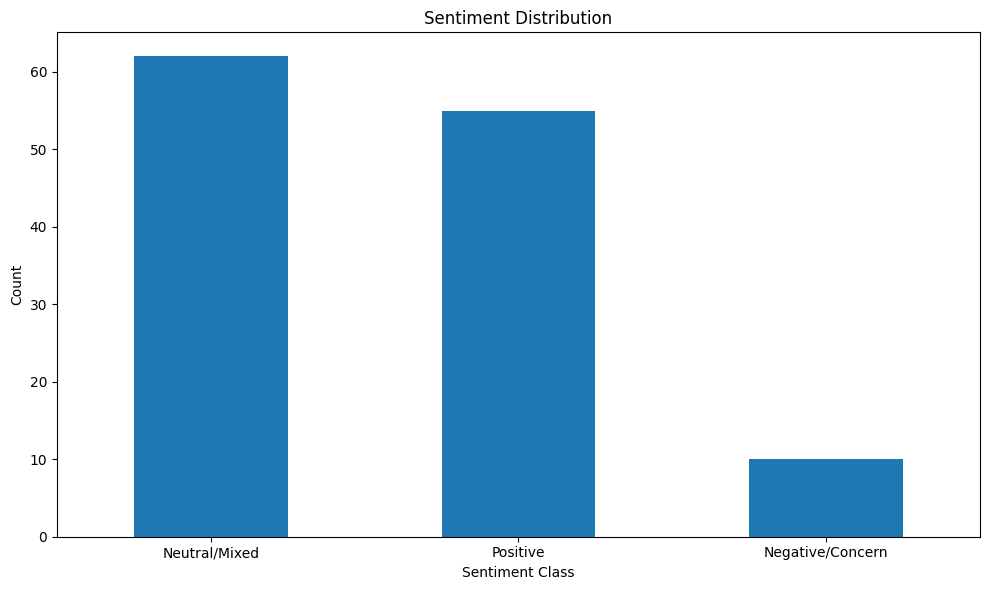

In [17]:

# 15. Sentiment analysis using TextBlob polarity

analysis_df["polarity"] = analysis_df["combined_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
analysis_df["subjectivity"] = analysis_df["combined_text"].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

# Use dataset-sensitive thresholds because many answers are nuanced and semi-positive in wording
def polarity_to_label(score):
    if score <= 0.04:
        return "Negative/Concern"
    elif score <= 0.11:
        return "Neutral/Mixed"
    return "Positive"

analysis_df["sentiment_label"] = analysis_df["polarity"].apply(polarity_to_label)

sentiment_counts = analysis_df["sentiment_label"].value_counts()
display(sentiment_counts.to_frame("count"))
display(analysis_df[["polarity", "subjectivity", "sentiment_label"]].describe(include="all"))

plt.figure()
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [18]:

# 16. Review sample responses from each sentiment bucket

for label in analysis_df["sentiment_label"].unique():
    print("\n" + "=" * 100)
    print("SENTIMENT:", label)
    subset = analysis_df.loc[analysis_df["sentiment_label"] == label, "combined_text"].head(2).tolist()
    for i, txt in enumerate(subset, 1):
        print(f"\nExample {i}:")
        print(txt[:800], "...")



SENTIMENT: Neutral/Mixed

Example 1:
I remember subscribing to Coursera since many of my friends recommended it. Eventually I decided the cost was not worth the value I was getting. If I break it down: the service quality was okay overall. Pricing was the main concern for me. The app design was simple enough to use daily. I didn't interact much with support, but innovation on the platform felt limited. At first it became part of my daily routine. Later my usage dropped because work became busy. The turning point came after noticing some consistent problems. The platform sometimes felt repetitive and predictable. That gradually influenced my decision to cancel the subscription. From an emotional perspective, initially I was quite satisfied. A better value plan could definitely bring me back. ...

Example 2:
At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it. Regarding quality, it was decent but not outstanding. Pr

## 6. Topic Modeling (LDA)

In [19]:

# 17. LDA topic modeling

NUM_TOPICS = 5
TOP_WORDS = 10

lda_vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words="english")
lda_X = lda_vectorizer.fit_transform(analysis_df["clean_text"])

lda_model = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    random_state=42,
    learning_method="batch"
)
lda_model.fit(lda_X)

feature_names = lda_vectorizer.get_feature_names_out()

def get_topic_terms(model, feature_names, n_top_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics[f"Topic {topic_idx + 1}"] = top_features
    return topics

topics = get_topic_terms(lda_model, feature_names, TOP_WORDS)
topics_df = pd.DataFrame({
    "topic": list(topics.keys()),
    "top_words": [", ".join(v) for v in topics.values()]
})
topics_df


,topic,top_words
0,Topic 1,"eventually, plan, noticeable, fresh, lack, getting, decided, cost, worth, pushed"
1,Topic 2,"app, daily, okay, interact, innovation, design, break, limited, concern, simple"
2,Topic 3,"definitely, improvements, main, observation, usability, reasonably, match, introduce, good, didn"
3,Topic 4,"point, app, monthly, technically, updates, inside, fine, rare, navigation, smooth"
4,Topic 5,"time, occasional, perspective, outstanding, lag, regarding, polite, slow, indian, easy"


,count
dominant_topic,
1,1
2,34
3,30
4,36
5,26


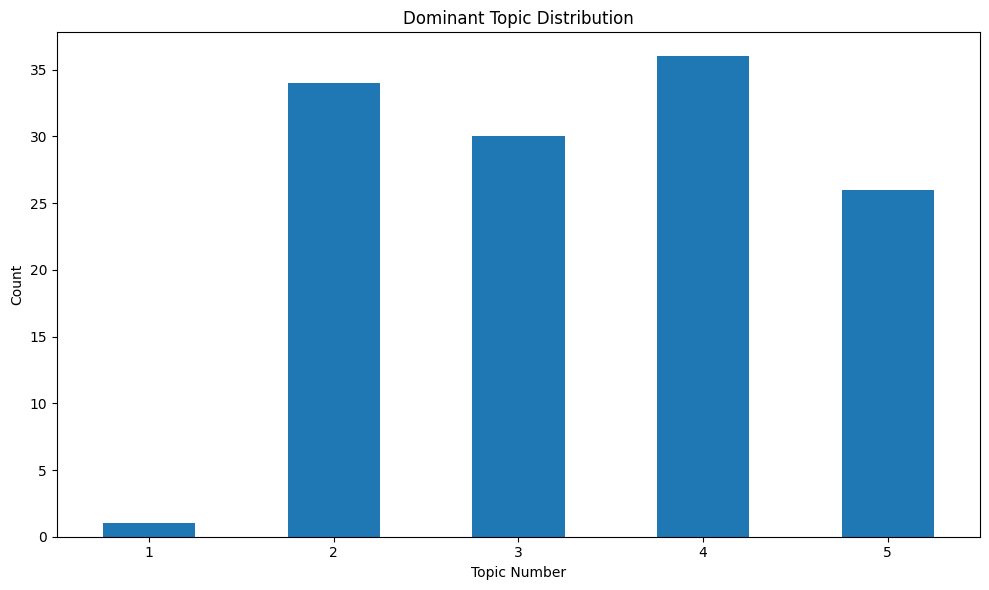

In [20]:

# 18. Assign dominant topic to each response

topic_probabilities = lda_model.transform(lda_X)
analysis_df["dominant_topic"] = topic_probabilities.argmax(axis=1) + 1

topic_distribution = analysis_df["dominant_topic"].value_counts().sort_index()
display(topic_distribution.to_frame("count"))

plt.figure()
topic_distribution.plot(kind="bar")
plt.title("Dominant Topic Distribution")
plt.xlabel("Topic Number")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [21]:

# 19. Show sample responses by topic

for topic_num in sorted(analysis_df["dominant_topic"].unique()):
    print("\n" + "=" * 100)
    print(f"TOPIC {topic_num}")
    print("Keywords:", topics_df.loc[topics_df["topic"] == f"Topic {topic_num}", "top_words"].iloc[0])
    sample_texts = analysis_df.loc[analysis_df["dominant_topic"] == topic_num, "combined_text"].head(2).tolist()
    for i, txt in enumerate(sample_texts, 1):
        print(f"\nExample {i}:")
        print(txt[:800], "...")



TOPIC 1
Keywords: eventually, plan, noticeable, fresh, lack, getting, decided, cost, worth, pushed

Example 1:
The subscription I cancelled recently was Cult Fit mainly out of curiosity. Eventually I decided the cost was not worth the value I was getting. The service itself worked reasonably well. My main observation was that the value didn't always match the subscription price. Usability was good, though the platform could definitely introduce more improvements. In the beginning I used it quite frequently. Eventually weeks would pass without me using it. The problems were not huge but they kept adding up. The lack of fresh content became noticeable. That gradually influenced my decision to cancel the subscription. From an emotional perspective, initially I was quite satisfied. Right now I don't plan to return, but that could change if things improve. ...

TOPIC 2
Keywords: app, daily, okay, interact, innovation, design, break, limited, concern, simple

Example 1:
I remember subscribi

## 7. Word Co-occurrence Network

In [22]:

# 20. Build a word co-occurrence network from top terms

top_terms_for_network = set(top_unigrams.head(25)["term"])

def get_cooccurrence_edges(text, vocab):
    tokens = [t for t in text.split() if t in vocab]
    unique_tokens = list(dict.fromkeys(tokens))
    edges = []
    for i in range(len(unique_tokens)):
        for j in range(i + 1, len(unique_tokens)):
            edges.append((unique_tokens[i], unique_tokens[j]))
    return edges

edge_counter = Counter()
for txt in analysis_df["clean_text"]:
    edge_counter.update(get_cooccurrence_edges(txt, top_terms_for_network))

G = nx.Graph()
for (a, b), weight in edge_counter.items():
    if weight >= 8:
        G.add_edge(a, b, weight=weight)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
list(G.edges(data=True))[:10]


Nodes: 20
Edges: 189


[('main', 'app', {'weight': 15}),
 ('main', 'didn', {'weight': 65}),
 ('main', 'routine', {'weight': 17}),
 ('main', 'point', {'weight': 9}),
 ('main', 'gradually', {'weight': 17}),
 ('main', 'influenced', {'weight': 65}),
 ('main', 'decision', {'weight': 65}),
 ('main', 'initially', {'weight': 25}),
 ('main', 'plan', {'weight': 29}),
 ('main', 'definitely', {'weight': 42})]

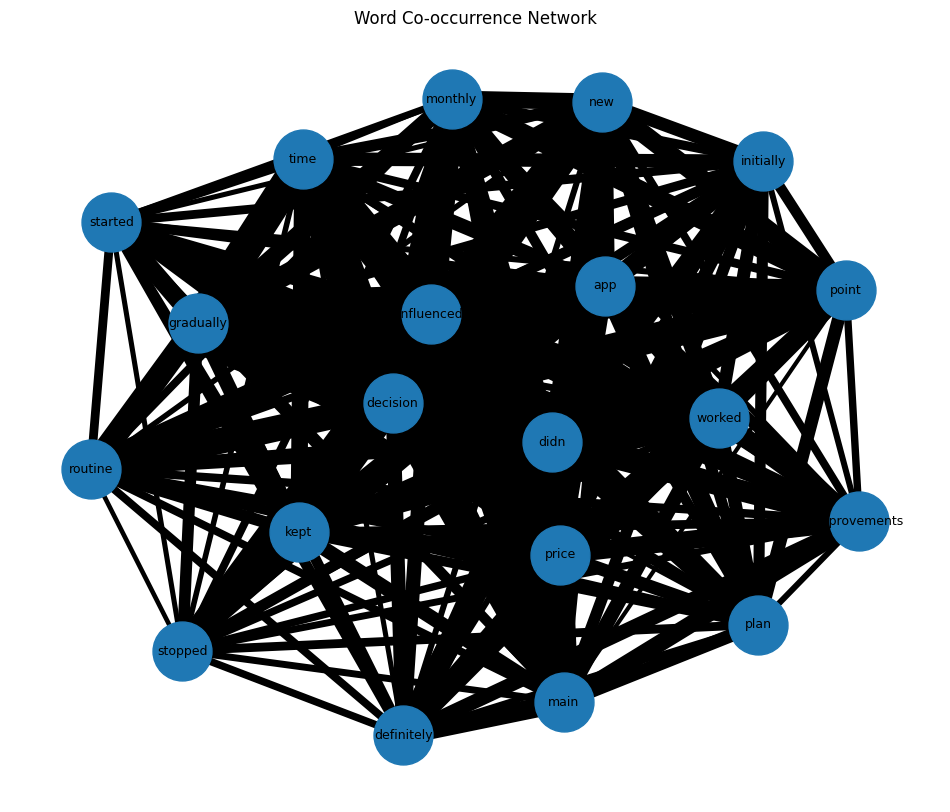

In [23]:

# 21. Plot the co-occurrence network

plt.figure(figsize=(12, 10))

if G.number_of_nodes() > 0:
    pos = nx.spring_layout(G, k=0.8, seed=42)
    edge_widths = [G[u][v]["weight"] / 3 for u, v in G.edges()]
    nx.draw_networkx(
        G,
        pos=pos,
        with_labels=True,
        node_size=1800,
        font_size=9,
        width=edge_widths
    )
    plt.title("Word Co-occurrence Network")
    plt.axis("off")
    plt.show()
else:
    print("No network graph created. Lower the edge-weight threshold if needed.")


## 8. Clustering

,k,silhouette_score
0,2,0.084165
1,3,0.109529
2,4,0.138108
3,5,0.106379
4,6,0.086755


Best k based on silhouette score: 4


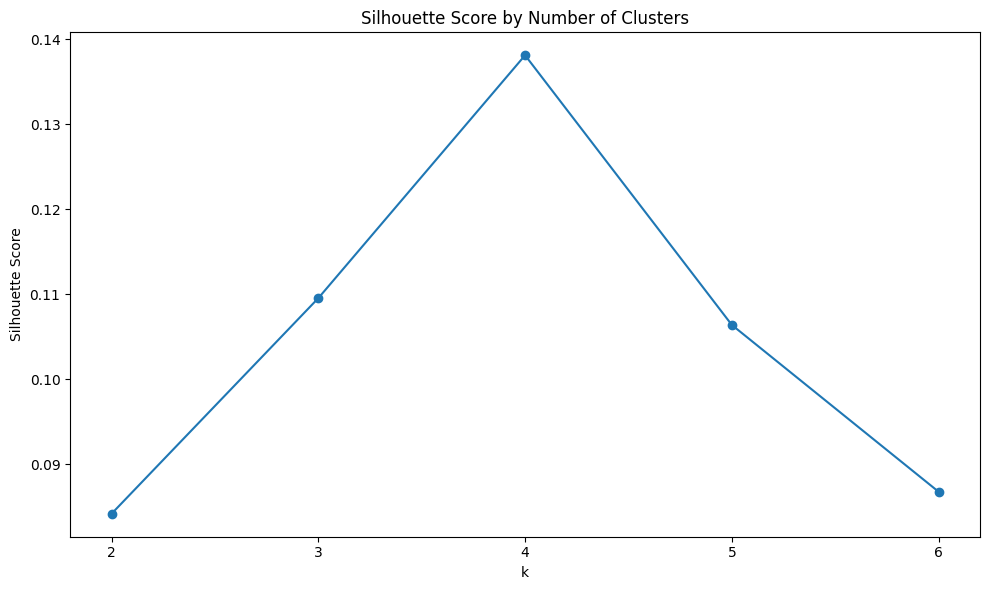

In [24]:

# 22. Cluster responses using TF-IDF + KMeans

tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(analysis_df["clean_text"])

candidate_k = range(2, 7)
silhouette_scores = []

for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_tfidf)
    score = silhouette_score(X_tfidf, labels)
    silhouette_scores.append((k, score))

silhouette_df = pd.DataFrame(silhouette_scores, columns=["k", "silhouette_score"])
display(silhouette_df)

best_k = silhouette_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
best_k = int(best_k)
print("Best k based on silhouette score:", best_k)

plt.figure()
plt.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.xticks(list(candidate_k))
plt.tight_layout()
plt.show()


In [25]:

# 23. Fit final KMeans model and inspect cluster keywords

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
analysis_df["cluster"] = kmeans.fit_predict(X_tfidf)

terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

cluster_keywords = {}
for i in range(best_k):
    cluster_keywords[i] = [terms[ind] for ind in order_centroids[i, :12]]

cluster_keywords_df = pd.DataFrame({
    "cluster": list(cluster_keywords.keys()),
    "keywords": [", ".join(v) for v in cluster_keywords.values()]
})
display(cluster_keywords_df)

cluster_counts = analysis_df["cluster"].value_counts().sort_index()
display(cluster_counts.to_frame("count"))


,cluster,keywords
0,0,"time, fairly, easy navigate, decent outstanding, expected, expected new, easy, indian perspective, interface, interface fairly, high, fairly easy"
1,1,"app design, break, daily didn, design, design simple, didn interact, concern app, concern, break okay, okay, main concern, innovation limited"
2,2,"usability, usability good, match price, price usability, observation didn, reasonably, reasonably main, worked reasonably, match, introduce improvements, introduce, good"
3,3,"updates, app smooth, view, updates new, new rare, navigation inside, view worked, justified navigation, justified, smooth, inside app, inside"


,count
cluster,
0,26
1,34
2,31
3,36


In [26]:

# 24. Sample responses from each cluster

for cluster_id in sorted(analysis_df["cluster"].unique()):
    print("\n" + "=" * 100)
    print(f"CLUSTER {cluster_id}")
    print("Keywords:", cluster_keywords_df.loc[cluster_keywords_df["cluster"] == cluster_id, "keywords"].iloc[0])
    sample_texts = analysis_df.loc[analysis_df["cluster"] == cluster_id, "combined_text"].head(2).tolist()
    for i, txt in enumerate(sample_texts, 1):
        print(f"\nExample {i}:")
        print(txt[:800], "...")



CLUSTER 0
Keywords: time, fairly, easy navigate, decent outstanding, expected, expected new, easy, indian perspective, interface, interface fairly, high, fairly easy

Example 1:
At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it. Regarding quality, it was decent but not outstanding. Pricing felt slightly high from an Indian perspective. The interface itself was fairly easy to navigate, although I noticed occasional lag. Customer support was polite but slow, and I expected more new features over time. In the beginning I used it quite frequently. But gradually I stopped opening the app as often. The problems were not huge but they kept adding up. Paying monthly for something I hardly used started bothering me. That gradually influenced my decision to cancel the subscription. Reflecting on the experience, initially I was quite satisfied. If the company improves pricing or features I might consid ...

Example 2:
I ha

## 9. Weakly Supervised Target: Return Intent / Retention Opportunity

In [27]:

# 25. Create a simple target label from the final open-ended question
# This is a practical CIA4-friendly workaround because the dataset does not contain a ready-made target column.

def infer_return_intent(text: str) -> str:
    t = str(text).lower()

    positive_patterns = [
        r"\bbring me back\b",
        r"\bconsider returning\b",
        r"\bsubscribe again\b",
        r"\breconsider using\b",
        r"\breturn if\b",
        r"\bcome back if\b",
        r"\bmight consider returning\b",
        r"\bwould consider returning\b",
        r"\bdefinitely bring me back\b",
        r"\bmight subscribe again\b"
    ]

    negative_patterns = [
        r"\bdon't plan to return\b",
        r"\bdo not plan to return\b",
        r"\bwould not return\b",
        r"\bwill not return\b",
        r"\bunlikely to return\b",
        r"\bnot interested in returning\b",
        r"\bwon't return\b"
    ]

    if any(re.search(p, t) for p in negative_patterns):
        return "Unlikely_Return"

    if any(re.search(p, t) for p in positive_patterns):
        return "Likely_Return"

    # fallback heuristics
    if ("return" in t or "reconsider" in t or "subscribe again" in t) and ("if" in t or "improve" in t or "better" in t):
        return "Likely_Return"

    return "Unclear"

analysis_df["return_intent"] = analysis_df["emotional_loyalty_future"].apply(infer_return_intent)
analysis_df["return_intent"].value_counts(dropna=False)


return_intent
Likely_Return      101
Unlikely_Return     26
Name: count, dtype: int64

In [28]:

# 26. Keep only clear labels for modeling

model_df = analysis_df[analysis_df["return_intent"].isin(["Likely_Return", "Unlikely_Return"])].copy()
print("Rows kept for classification:", len(model_df))
display(model_df["return_intent"].value_counts().to_frame("count"))


Rows kept for classification: 127


,count
return_intent,
Likely_Return,101
Unlikely_Return,26


## 10. Classification Models

In [29]:

# 27. Train/test split

X = model_df["clean_text"]
y = model_df["return_intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Target distribution in training set:")
display(y_train.value_counts().to_frame("count"))


Train size: 95
Test size: 32
Target distribution in training set:


,count
return_intent,
Likely_Return,76
Unlikely_Return,19


In [30]:

# 28. Train multiple models

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    results.append({
        "model": name,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    })

results_df = pd.DataFrame(results).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
results_df


,model,accuracy,macro_f1,weighted_f1
0,Linear SVM,1.00000,1.000000,1.000000
1,Random Forest,1.00000,1.000000,1.000000
2,Naive Bayes,0.84375,0.676768,0.807449
3,Logistic Regression,0.78125,0.438596,0.685307


Best model: Linear SVM
                 precision    recall  f1-score   support

  Likely_Return       1.00      1.00      1.00        25
Unlikely_Return       1.00      1.00      1.00         7

       accuracy                           1.00        32
      macro avg       1.00      1.00      1.00        32
   weighted avg       1.00      1.00      1.00        32



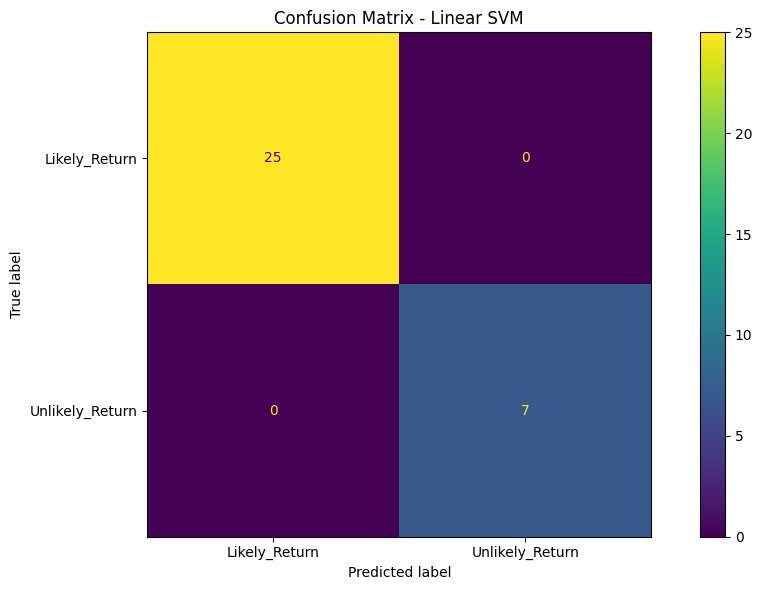

In [31]:

# 29. Detailed evaluation for the best model

best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
best_model.fit(X_train_vec, y_train)
best_preds = best_model.predict(X_test_vec)

print("Best model:", best_model_name)
print(classification_report(y_test, best_preds, zero_division=0))

cm = confusion_matrix(y_test, best_preds, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


In [33]:

# 30. Most important predictive terms (where available)

feature_names = vectorizer.get_feature_names_out()

if hasattr(best_model, "coef_"):
    coef = best_model.coef_[0]
    coef_df = pd.DataFrame({
        "term": feature_names,
        "coefficient": coef
    }).sort_values("coefficient")

    print("Terms pushing toward Unlikely_Return")
    display(coef_df.head(15))

    print("Terms pushing toward Likely_Return")
    display(coef_df.tail(15).sort_values("coefficient", ascending=False))
else:
    print("This model does not expose linear coefficients directly.")


Terms pushing toward Unlikely_Return


,term,coefficient
46,better,-0.397469
47,better plan,-0.397469
52,bring,-0.397469
111,definitely bring,-0.397469
348,plan definitely,-0.397469
110,definitely,-0.348920
268,meaningful improvements,-0.347122
485,subscribe,-0.347122
196,improvements subscribe,-0.347122
267,meaningful,-0.347122


Terms pushing toward Likely_Return


,term,coefficient
349,plan return,1.121915
126,don plan,1.121915
192,improve,1.121915
421,right,1.121915
418,return,1.121915
419,return change,1.121915
422,right don,1.121915
61,change,1.121915
125,don,1.121915
62,change improve,1.121915


## 11. Business Interpretation Tables

In [34]:

# 31. Build an interpretation-ready table of key churn drivers and retention opportunities

# Simple keyword buckets you can discuss in the report/presentation
driver_dict = {
    "Price/Value": ["price", "pricing", "expensive", "cost", "worth", "value"],
    "Low Usage": ["rarely", "busy", "usage", "used", "time", "routine"],
    "Feature Gap": ["limited", "features", "innovation", "repetitive", "predictable"],
    "UX/Technical Issues": ["technical", "issue", "bug", "difficult", "convenience", "usability", "slow"],
    "Alternatives/Competition": ["alternative", "competitor", "better", "elsewhere"],
    "Need Change": ["need", "needs", "personal", "change", "declined"]
}

def bucket_hits(text, keywords):
    tokens = set(text.split())
    return int(any(k in tokens for k in keywords))

for bucket, keywords in driver_dict.items():
    analysis_df[bucket] = analysis_df["clean_text"].apply(lambda x: bucket_hits(x, keywords))

bucket_summary = (
    analysis_df[list(driver_dict.keys())]
    .sum()
    .sort_values(ascending=False)
    .rename("response_count")
    .reset_index()
    .rename(columns={"index": "driver_bucket"})
)

bucket_summary["share_of_responses"] = (bucket_summary["response_count"] / len(analysis_df)).round(3)
bucket_summary


,driver_bucket,response_count,share_of_responses
0,Low Usage,112,0.882
1,Price/Value,76,0.598
2,UX/Technical Issues,57,0.449
3,Feature Gap,51,0.402
4,Alternatives/Competition,33,0.260
5,Need Change,26,0.205


In [35]:

# 32. Retention opportunity summary from responses marked as Likely_Return

likely_return_df = analysis_df[analysis_df["return_intent"] == "Likely_Return"].copy()
print("Likely-return rows:", len(likely_return_df))

retention_terms = top_ngrams(likely_return_df["clean_text"], ngram_range=(1, 2), top_n=20, min_df=2)
retention_terms


Likely-return rows: 101


,term,frequency
0,gradually,160
1,decision,128
2,time,119
3,app,108
4,gradually influenced,101
5,influenced,101
6,influenced decision,101
7,didn,80
8,started,76
9,definitely,60



### Suggested interpretation angles for your report/presentation
Use the outputs above to write findings such as:
- the most frequent churn drivers
- what people still liked before leaving
- which issues appear together in the co-occurrence network
- which LDA topics dominate the dataset
- whether there is a realistic segment of users who may return if the service improves pricing, value, usability, or features


## 12. Export Outputs

In [36]:

# 33. Export cleaned data and summary tables for report writing

analysis_df.to_csv(os.path.join(OUTPUT_DIR, "cleaned_subscription_churn_analysis.csv"), index=False)
top_unigrams.to_csv(os.path.join(OUTPUT_DIR, "top_unigrams.csv"), index=False)
top_bigrams.to_csv(os.path.join(OUTPUT_DIR, "top_bigrams.csv"), index=False)
top_trigrams.to_csv(os.path.join(OUTPUT_DIR, "top_trigrams.csv"), index=False)
topics_df.to_csv(os.path.join(OUTPUT_DIR, "lda_topics.csv"), index=False)
cluster_keywords_df.to_csv(os.path.join(OUTPUT_DIR, "cluster_keywords.csv"), index=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, "classification_model_results.csv"), index=False)
bucket_summary.to_csv(os.path.join(OUTPUT_DIR, "driver_bucket_summary.csv"), index=False)

print("Exported files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print("-", f)


Exported files:
- classification_model_results.csv
- cleaned_subscription_churn_analysis.csv
- cluster_keywords.csv
- driver_bucket_summary.csv
- lda_topics.csv
- top_bigrams.csv
- top_trigrams.csv
- top_unigrams.csv



## 13. Final write-up checklist

Before submission, make sure you add:
1. **Problem statement**
2. **Dataset description**
3. **Preprocessing steps**
4. **Exploratory findings**
5. **Sentiment analysis results**
6. **Topic modeling results**
7. **Clustering and co-occurrence insights**
8. **AI / classification section**
9. **Business implications**
10. **Prompt log used for coding**

### Suggested presentation flow
- Introduction and business context
- Research questions
- Dataset and methodology
- EDA + word cloud + top n-grams
- Sentiment findings
- Topic modeling
- Network analysis
- Classification / return-intent prediction
- Business implications and retention strategies
- Conclusion
